# 03 -- Time-Aware Labelling + Windowing

* Healthy windows come **only** from dedicated healthy runs.
* Fault windows come **only** from the fault-active region (`t >= fault time`,
  or the whole run for the always-on generator fault).
* Windows lie entirely inside their region; 50% stride.
* Saves raw windowed sequences (for the LSTM league) + per-run window counts.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
%matplotlib inline
import pdm_common as P

from pathlib import Path
P.RAW_DIR = Path(r"E:\DRDO\Sarthak Dhaigude_DRDO\PdM-main\RAW_DIR\raw")

import json, numpy as np, pandas as pd

In [2]:
clean = pd.read_parquet(P.ART_DIR / "clean_runs.parquet")
common = json.loads((P.ART_DIR / "common_signals.json").read_text())

seqs, meta, counts = [], [], []
for rid, g in clean.groupby("run_id"):
    g = g.sort_values("time").reset_index(drop=True)
    label, always_on = g["label"].iloc[0], bool(g["always_on"].iloc[0])
    n = 0
    for t_start, seg in P.iter_windows(g[["time"] + common], always_on):
        seqs.append(np.stack([seg[s] for s in common], axis=-1))
        meta.append(dict(run_id=rid, label=label, t_start=t_start))
        n += 1
    counts.append(dict(run_id=rid, label=label, n_windows=n, included=n >= P.MIN_WINDOWS))

cnt = pd.DataFrame(counts)
cnt.to_csv(P.ART_DIR / "window_counts.csv", index=False)

keep = set(cnt.loc[cnt["included"], "run_id"])
mask = np.array([m["run_id"] in keep for m in meta])
X_seq = np.asarray(seqs)[mask]
meta_df = pd.DataFrame(meta)[mask].reset_index(drop=True)
np.savez_compressed(P.ART_DIR / "windows.npz", X=X_seq,
                    run_id=meta_df["run_id"].to_numpy(),
                    label=meta_df["label"].to_numpy(), signals=np.array(common))
print(f"Total windows kept: {len(meta_df)}  shape={X_seq.shape}")

Total windows kept: 267  shape=(267, 200, 4)


## Windows per run

In [3]:
cnt

,run_id,label,n_windows,included
0,Healthy Data 3,Healthy,9,True
1,Leakage_factor,Leakage,9,True
2,Medium_FlexibleShaft_Fault,FlexibleShaft,19,True
3,MildFlexible_shaft,FlexibleShaft,18,True
4,disp1_fault(0.5),PumpDisplacement,19,True
5,disp2_fault(0.3),PumpDisplacement,19,True
6,disp3_fault(0.2),PumpDisplacement,19,True
7,leakage_fault(0.5),Leakage,17,True
8,leakage_fault(1.0),Leakage,17,True
9,pump_disp(st-0.5),PumpDisplacement,39,True


## Windows per class

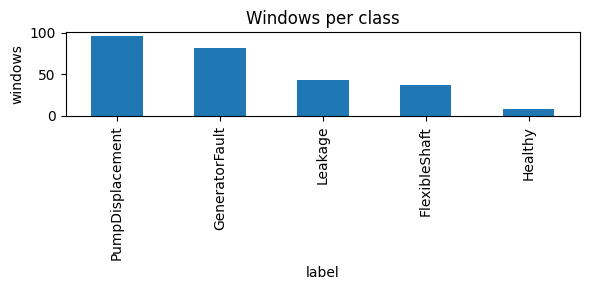

label
PumpDisplacement    96
GeneratorFault      82
Leakage             43
FlexibleShaft       37
Healthy              9
Name: count, dtype: int64

In [4]:
import matplotlib.pyplot as plt
wc = meta_df["label"].value_counts()
ax = wc.plot.bar(figsize=(6, 3), title="Windows per class")
ax.set_ylabel("windows"); plt.tight_layout(); plt.show()
wc

## Runs per class (after the MIN_WINDOWS filter)

In [5]:
runs_per_class = cnt[cnt.included].groupby("label")["run_id"].nunique()
single = sorted(runs_per_class.index[runs_per_class < 2])
if single:
    print(f"Single-run classes {single}: cannot be split train/test in grouped CV "
          "-> their CV scores are the honest worst case, reported as-is.")
else:
    print("All classes have >=2 runs -> grouped CV can validate every class leakage-free.")
runs_per_class

Single-run classes ['Healthy']: cannot be split train/test in grouped CV -> their CV scores are the honest worst case, reported as-is.


label
FlexibleShaft       2
GeneratorFault      3
Healthy             1
Leakage             3
PumpDisplacement    4
Name: run_id, dtype: int64